Seasonal Naive Basline Model


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error


In [4]:
path = '/content/drive/Shareddrives/Time Series Group 5/Final_Project/data/monthly_counts/'

files = sorted(glob.glob(os.path.join(path, "*.csv")))
print(files)

df_list = [pd.read_csv(f) for f in files]
df = pd.concat(df_list, ignore_index=True)

['/content/drive/Shareddrives/Time Series Group 5/Final_Project/data/monthly_counts/monthly_13_23.csv', '/content/drive/Shareddrives/Time Series Group 5/Final_Project/data/monthly_counts/monthly_24_26.csv']


In [7]:
# Data cleaning
df["month"] = pd.to_datetime(df["month"])
df = df.sort_values("month").reset_index(drop=True)

# drop last 2026-01-01 row
df = df.iloc[:-1]

In [8]:
# Baseline Models

# Naive: last month = this month
df["naive_pred"] = df["num_trips"].shift(1)

# Seasonal Naive: same month last year
df["seasonal_naive_pred"] = df["num_trips"].shift(12)

In [9]:
# train test split
test_horizon = 12   # last 12 months as test
train = df.iloc[:-test_horizon]
test  = df.iloc[-test_horizon:]

In [10]:
# evaluation function
def evaluate(y_true, y_pred):
    mask = (~pd.isna(y_true)) & (~pd.isna(y_pred))
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return rmse, mae, mape


In [11]:
# performance evaluation

rmse_n, mae_n, mape_n = evaluate(test["num_trips"], test["naive_pred"])
rmse_s, mae_s, mape_s = evaluate(test["num_trips"], test["seasonal_naive_pred"])

In [12]:
print("Naive (t-1)")
print("RMSE:", rmse_n)
print("MAE :", mae_n)
print("MAPE:", mape_n, "%\n")

Naive (t-1)
RMSE: 62021.21595940645
MAE : 48505.583333333336
MAPE: 8.955501674204529 %



In [13]:
print("Seasonal Naive (t-12)")
print("RMSE:", rmse_s)
print("MAE :", mae_s)
print("MAPE:", mape_s, "%")

Seasonal Naive (t-12)
RMSE: 36034.76866745042
MAE : 32217.916666666668
MAPE: 5.4460139595400605 %


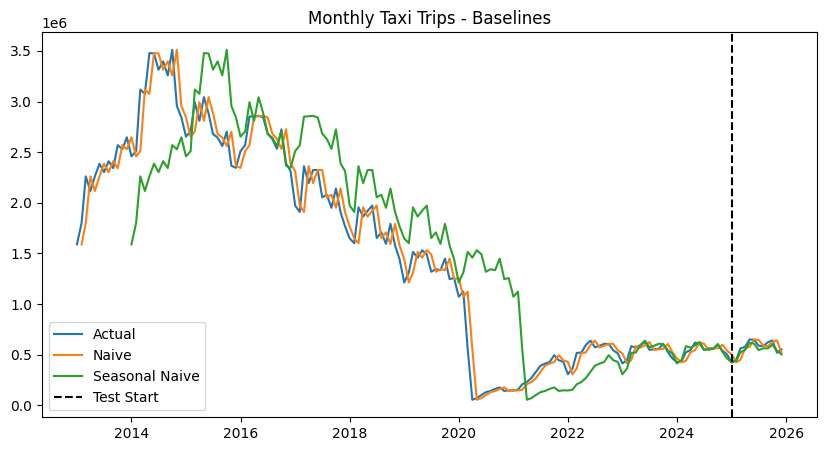

In [14]:
plt.figure(figsize=(10,5))
plt.plot(df["month"], df["num_trips"], label="Actual")
plt.plot(df["month"], df["naive_pred"], label="Naive")
plt.plot(df["month"], df["seasonal_naive_pred"], label="Seasonal Naive")
plt.axvline(test["month"].iloc[0], linestyle="--", color="black", label="Test Start")
plt.legend()
plt.title("Monthly Taxi Trips - Baselines")
plt.show()